In [1]:
!apt update -q
!apt-get install -q openjdk-11-jdk-headless

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Hit:3 http://archive.ubuntu.com/ubuntu noble InRelease
Get:4 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Get:6 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:7 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease [17.8 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.3 MB]
Get:10 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 Packages [2,164 kB]
Get:11 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 Packages [1,695 kB]
Get:12 http://archive.ubuntu.com/ubuntu noble-updates/restricted amd64 Packages [2,135 kB]
Get:13 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble/main amd64 Packages

In [3]:
from getpass import getpass
import os

os.environ["TWELVE_DATA_API_KEY"] = getpass("Enter your Twelve Data API key: ")

Enter your Twelve Data API key: ··········


In [4]:
%%writefile App.java
import java.io.BufferedReader;
import java.io.InputStreamReader;
import java.net.HttpURLConnection;
import java.net.URL;
import java.time.LocalDateTime;
import java.util.LinkedList;
import java.util.Queue;

public class App {

    public static class DataPoint {
        private double price;
        private LocalDateTime timestamp;

        public DataPoint(double price, LocalDateTime timestamp) {
            this.price = price;
            this.timestamp = timestamp;
        }

        public double getPrice() {
            return price;
        }

        public LocalDateTime getTimestamp() {
            return timestamp;
        }

        @Override
        public String toString() {
            return "price=" + price + ", timestamp=" + timestamp;
        }
    }

    public static void main(String[] args) {
        String apiKey = System.getenv("TWELVE_DATA_API_KEY");
        if (apiKey == null || apiKey.isEmpty()) {
            System.err.println("Error: TWELVE_DATA_API_KEY environment variable is not set.");
            return;
        }

        String urlString = "https://api.twelvedata.com/price?symbol=DIA&apikey=" + apiKey;
        Queue<DataPoint> dataQueue = new LinkedList<>();

        int iterations = 5;

        for (int i = 0; i < iterations; i++) {
            try {
                URL url = new URL(urlString);
                HttpURLConnection conn = (HttpURLConnection) url.openConnection();
                conn.setRequestMethod("GET");

                BufferedReader reader = new BufferedReader(new InputStreamReader(conn.getInputStream()));
                StringBuilder response = new StringBuilder();
                String line;

                while ((line = reader.readLine()) != null) {
                    response.append(line);
                }
                reader.close();

                String jsonResponse = response.toString();
                double price = 0.0;
                if (jsonResponse.contains("price")) {
                    String priceStr = jsonResponse.split("\"price\"\\s*:\\s*\"")[1].split("\"")[0];
                    price = Double.parseDouble(priceStr);
                }

                LocalDateTime now = LocalDateTime.now();
                DataPoint dataPoint = new DataPoint(price, now);
                dataQueue.add(dataPoint);

                System.out.println("Added data point: " + dataPoint);
                System.out.println("Current queue size: " + dataQueue.size());

                if (i < iterations - 1) {
                    Thread.sleep(15000);
                }

            } catch (Exception e) {
                System.err.println("Error fetching market data: " + e.getMessage());
            }
        }
    }
}

Writing App.java


In [5]:
import subprocess
import os

print("API key found:", bool(os.getenv("TWELVE_DATA_API_KEY")))

compile_result = subprocess.run(
    ["javac", "App.java"],
    capture_output=True,
    text=True
)

print("Compile return code:", compile_result.returncode)

if compile_result.stdout:
    print("Compile output:")
    print(compile_result.stdout)

if compile_result.stderr:
    print("Compile errors:")
    print(compile_result.stderr)

if compile_result.returncode == 0:
    run_result = subprocess.run(
        ["java", "App"],
        capture_output=True,
        text=True,
        env=os.environ
    )

    print("Run return code:", run_result.returncode)

    print("Application output:")
    print(run_result.stdout)

    if run_result.stderr:
        print("Application errors:")
        print(run_result.stderr)
else:
    print("Your Java file did not compile. Review the errors above before running the application.")

API key found: True
Compile return code: 0
Compile output:
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate

Compile errors:
Note: App.java uses or overrides a deprecated API.
Note: Recompile with -Xlint:deprecation for details.

Run return code: 0
Application output:
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Added data point: price=512.099976, timestamp=2026-10-06T08:17:12.896106020
Current queue size: 1
Added data point: price=

        price                     timestamp
0  512.099976 2026-10-06 08:17:12.896106020
1  512.099976 2026-10-06 08:17:28.254113903
2  512.099976 2026-10-06 08:17:43.433572995
3  512.099976 2026-10-06 08:17:58.613794737
4  512.099976 2026-10-06 08:18:13.810136433


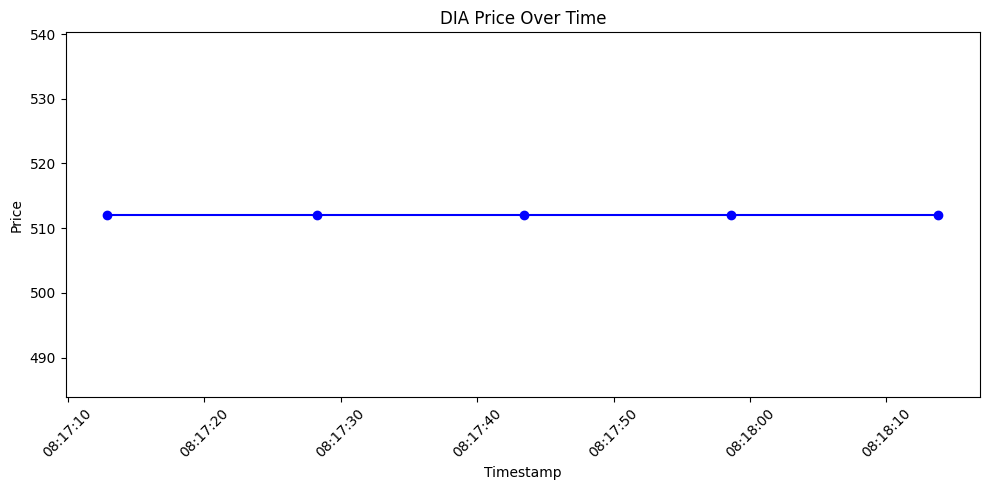

In [6]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Paste your Java output between the triple quotes below
java_output = """
Added data point: price=512.099976, timestamp=2026-10-06T08:17:12.896106020
Added data point: price=512.099976, timestamp=2026-10-06T08:17:28.254113903
Added data point: price=512.099976, timestamp=2026-10-06T08:17:43.433572995
Added data point: price=512.099976, timestamp=2026-10-06T08:17:58.613794737
Added data point: price=512.099976, timestamp=2026-10-06T08:18:13.810136433
"""

# Extract price and timestamp
matches = re.findall(
    r"price=([0-9.]+), timestamp=([^\n]+)",
    java_output
)

# Convert to DataFrame
df = pd.DataFrame(matches, columns=["price", "timestamp"])

# Convert data types
df["price"] = df["price"].astype(float)
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df)

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(df["timestamp"], df["price"], marker="o", color="b", linestyle="-")

plt.title("DIA Price Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Price")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()